In [1]:
import math


## 定义类

In [2]:
class Value:
    def __init__(self, data,_children=(),_op='',label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op =_op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data}, label='{self.label}')"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) #支持像是a+2的情况，把int转成Value
        out = Value(self.data + other.data, (self, other),'+',label=f"{self.label}+{other.label}")

        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward
        return out
    
    def __radd__(self, other): #支持像是2+a的情况
        return self + other
    
    def __neg__(self): #支持-a的情况
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other),'*',label=f"{self.label}*{other.label}")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out
    
    def __rmul__(self, other): #支持像是2*a的情况
        return self * other
    
    def __truediv__(self, other):
        return self * other**-1    
     
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,),'**',label=f"{self.label}**{other}")

        def _backward():
            self.grad += other * self.data ** (other-1) * out.grad

        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self,),'tanh',label=f"tanh({self.label})")

        def _backward():
            self.grad += (1-t**2) * out.grad 
        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,),'exp',label=f"exp({self.label})")

        def _backward():
            self.grad += out.data * out.grad 
        out._backward = _backward

        return out

 


    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

  

## 画图代码

In [3]:
import os
import shutil
from pathlib import Path

def _ensure_graphviz_dot():
    if shutil.which('dot'):
        return

    candidates = [
        Path(r'C:\Program Files\Graphviz\bin\dot.exe'),
        Path(r'C:\Program Files (x86)\Graphviz\bin\dot.exe'),
        Path(sys.prefix) / 'Library' / 'bin' / 'dot.exe',
    ]

    for dot_path in candidates:
        if dot_path.exists():
            os.environ['PATH'] = str(dot_path.parent) + os.pathsep + os.environ.get('PATH', '')
            return

    raise RuntimeError(
        'Graphviz executable dot.exe was not found. Install Graphviz or add its bin directory to PATH.'
    )

import sys
from graphviz import Digraph

_ensure_graphviz_dot()

def trace(root):
    # 收集从 root 出发能追溯到的所有节点和边
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root, format='svg', rankdir='LR'):
    """
    root: 最终输出节点
    format: 'svg', 'png' 等
    rankdir: 'LR' 表示从左到右, 'TB' 表示从上到下
    """
    assert rankdir in ['LR', 'TB']

    dot = Digraph(format=format, graph_attr={'rankdir': rankdir})
    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        # 每个 Value 节点画成一个 record
        dot.node(
            name=uid,
            label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad),
            shape='record'
        )

        # 如果这个节点是某个操作的结果，再额外画一个 op 节点
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # n1 --> n2 的“操作节点”
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

## 第一次完整测试

In [4]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')
x1w1 = x1*w1
x2w2 = x2*w2
x1w1x2w2 = x1w1 + x2w2
n = x1w1x2w2 + b
o = n.tanh()

o.grad = 1.0


In [5]:
o.backward()




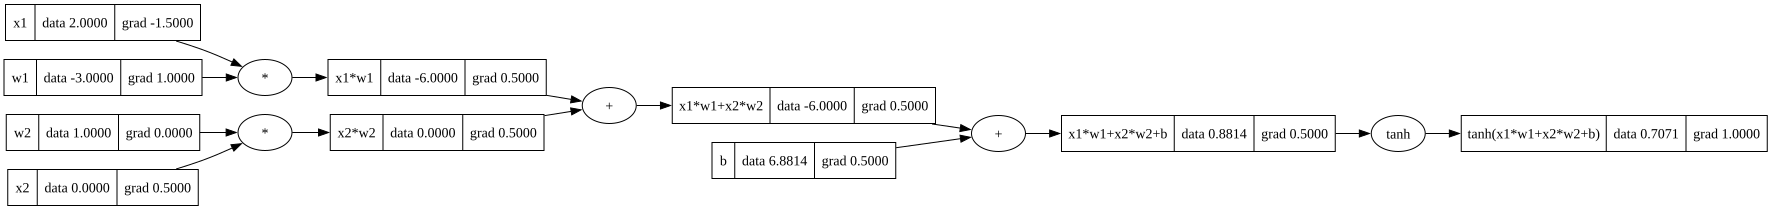

In [6]:
draw_dot(o)

## 梯度累加调整

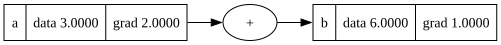

In [7]:
a = Value(3.0, label='a')
b = a + a ; b.label = 'b'
b.backward()
draw_dot(b)

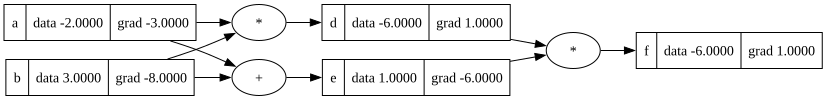

In [8]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b ; d.label = 'd'
e = a + b ; e.label = 'e'
f = d * e ; f.label = 'f'

f.backward()

draw_dot(f)

## 对于tanh的调整

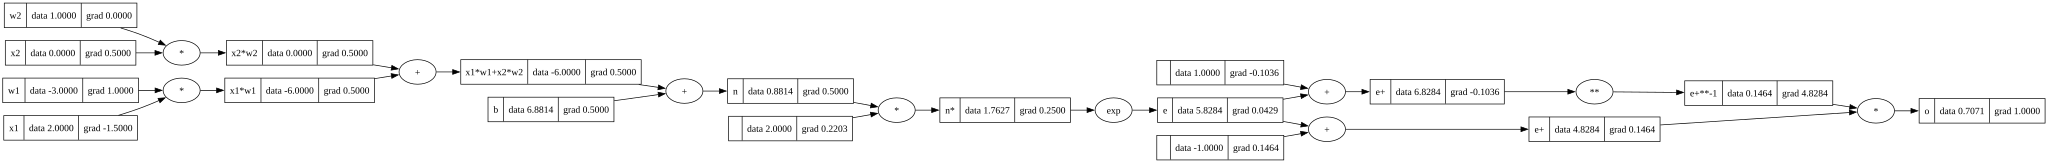

In [9]:
#将tanh 拆解为exp的形式

x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')
x1w1 = x1*w1
x2w2 = x2*w2
x1w1x2w2 = x1w1 + x2w2
n = x1w1x2w2 + b ; n.label = 'n'
e = (n*2).exp() ; e.label = 'e'
o = ( e - 1 )/ (e + 1) ; o.label = 'o'


o.grad = 1.0
o.backward()
draw_dot(o)


## pytorch

In [11]:
import torch 

x1 = torch.Tensor([2.0]).double()                     ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                     ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()                    ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                     ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()       ; b.requires_grad = True

n = x1 * w1 + x2 * w2 + b ; n.label = 'n'
o = torch.tanh(n) ; o.label = 'o'

print (o.data.item())
o.backward()

print("---")
print ('x1', x1.grad.item())
print ('x2', x2.grad.item())  
print ('w1', w1.grad.item())
print ('w2', w2.grad.item())

0.7071066904050358
---
x1 -1.5000003851533106
x2 0.5000001283844369
w1 1.0000002567688737
w2 0.0


In [13]:
x2.grad.item()

0.5000001283844369

## 2层感知机